# Round 2 Leakage Tool Prototype Cases

This notebook contains two independent real-CO2 prototype runs with the same toy geometry: a top-anchored case and a bottom-anchored reservoir-pressure case. It does not include dummy-fluid or SCREEN/WellClass work.

## Prerequisites

Running this notebook requires a local clone of the leakage tool prototype (`leakage_model` package) under `work/benchmark/repos/leakage_tool_prototype`:

```bash
mkdir -p work/benchmark/repos
git clone git@gitlab.sintef.no:1630/research-projects/legacy/leakage_tool_prototype.git work/benchmark/repos/leakage_tool_prototype
```

It also requires `thermopack` (used for the real-CO2 Peng-Robinson solver cases below). It is already listed in `pyproject.toml`, so `uv sync` should install it; if it is missing from your environment, run the cell below (or `uv add thermopack` from a terminal).

See [docs/openiam_benchmarking.md](../docs/openiam_benchmarking.md) for details. This checkout lives under the SCREEN-ignored `work/` folder and is not part of this repository.

In [1]:
# Uncomment to install thermopack into the current environment if it's missing
# !uv add thermopack

## Scope

Each case builds a fresh Peng-Robinson CO2 solver and fresh well geometry. The cases do not share solver state. The bottom-anchored case demonstrates the pressure-boundary customization required when reservoir pressure, rather than the CO2 column, is the source condition.

In [2]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "pyproject.toml").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "pyproject.toml").exists())

prototype_root = repo_root / "work" / "benchmark" / "repos" / "leakage_tool_prototype"
prototype_examples = prototype_root / "examples"
for path in (prototype_root, prototype_examples):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

round2_root = repo_root / "notebooks" / "results" / "08A_round2_leakage_tool_prototype"
round2_root.mkdir(parents=True, exist_ok=True)

if not prototype_root.exists():
    raise FileNotFoundError(
        f"Expected leakage_tool_prototype checkout at {prototype_root}\n"
        "Clone it under work/benchmark/repos/leakage_tool_prototype; see docs/openiam_benchmarking.md."
    )

prototype_root.relative_to(repo_root)

PosixPath('work/benchmark/repos/leakage_tool_prototype')

In [3]:
from leakage_model.flow_solver import FlowSolver
from leakage_model.plotting import visualizeAll
from leakage_model.reservoir_permeabilities import MILLIDARCY
from leakage_model.state import FormationBC, TopBC
import example_well_builder as prototype_bcs

## Prototype Case Definition

These values are copied from `simple_well_dummy_fluid.py`. Permeabilities are expressed in SI units (`m^2`) and converted to millidarcy only for the parameter summary.

In [4]:
well_length_m = 1000.0
n_cells = 40
r_bore_m = 0.1
microannulus_aperture_m = 1.0e-4
casing_thickness_m = 0.01

k_cement_m2 = 1.0e-16
phi_cement = 0.1
k_casing_m2 = 1.0e-19
phi_casing = 0.01

plug_intervals = [("Cement plug 1", 0.0, 150.0), ("Cement plug 2", 600.0, 750.0)]
open_bore_intervals = [("Open bore 1", 150.0, 600.0), ("Open bore 2", 750.0, 1000.0)]

k_microannulus_axial_m2 = microannulus_aperture_m ** 2 / 12.0
m_to_in = 1.0 / 0.0254

prototype_parameters = pd.DataFrame(
    [
        ["well_length_m", well_length_m, "m"],
        ["bore_radius_m", r_bore_m, "m"],
        ["microannulus_aperture_m", microannulus_aperture_m, "m"],
        ["microannulus_axial_perm_m2", k_microannulus_axial_m2, "m2"],
        ["microannulus_axial_perm_mD", k_microannulus_axial_m2 / MILLIDARCY, "mD"],
        ["cement_perm_m2", k_cement_m2, "m2"],
        ["cement_perm_mD", k_cement_m2 / MILLIDARCY, "mD"],
        ["casing_perm_m2", k_casing_m2, "m2"],
        ["casing_perm_mD", k_casing_m2 / MILLIDARCY, "mD"],
    ],
    columns=["quantity", "value", "unit"],
)
prototype_parameters

,quantity,value,unit
0,well_length_m,1.000000e+03,m
1,bore_radius_m,1.000000e-01,m
2,microannulus_aperture_m,1.000000e-04,m
3,microannulus_axial_perm_m2,8.333333e-10,m2
4,microannulus_axial_perm_mD,8.443750e+05,mD
5,cement_perm_m2,1.000000e-16,m2
6,cement_perm_mD,1.013250e-01,mD
7,casing_perm_m2,1.000000e-19,m2
8,casing_perm_mD,1.013250e-04,mD


## Standalone Real-CO2 Cases

Each case below builds a fresh well and solver. There is no shared solver state between the top-anchored and bottom-anchored runs.

## Bottom-Anchored CO2 Pressure Variant

The previous CO2 run is top-anchored: its hydrostatic profile starts from `P_TOP`. This variant instead prescribes an absolute reservoir pressure at the bottom, integrates the CO2 hydrostatic profile upward from that pressure, and uses the resulting profile for the formation boundary. This is closer to a reservoir-driven source condition, although the prototype remains single-fluid and uses CO2 properties for the formation state.

In [ ]:
co2_fs = FlowSolver(
    "round2_simple_well_top_anchored_co2",
    well_length_m,
    n_cells,
    thermo_model="pure_fluid",
    components="CO2",
    eos="PR",
    debug=False,
)
co2_fluid_model = "pure_fluid CO2 (thermopack PR)"

for name, top, bottom in plug_intervals:
    co2_fs.well.add_plug(name, r_bore_m - microannulus_aperture_m, top, bottom, k_cement_m2, phi_cement)
for name, top, bottom in open_bore_intervals:
    co2_fs.well.add_region_between_plugs(name, r_bore_m, top, bottom)
for index, (_, top, bottom) in enumerate(plug_intervals, start=1):
    co2_fs.well.add_microannulus(f"Microannulus {index}", microannulus_aperture_m, top, bottom)
co2_fs.well.add_casing("Casing", casing_thickness_m, 0.0, well_length_m, k_casing_m2, phi_casing)
co2_fs.well.connect_horizontal_links()
co2_fs.well.connect_vertical_links()

co2_pressure_offset = 5.0e5
co2_windows = [(800.0, 1000.0, +co2_pressure_offset)]
prototype_bcs.set_water_bcs(
    co2_fs,
    co2_windows,
    top_open=False,
    bottom_open=True,
    bottom_dp=co2_pressure_offset,
)
co2_result = co2_fs.solve_system()

co2_flows = co2_result.flows.total()
co2_result_summary = pd.DataFrame(
    [
        ["fluid_model", co2_fluid_model],
        ["case", "top-anchored"],
        ["convergence_status", co2_result.convergence.status],
        ["top_pressure_bar", co2_fs.p_top / 1.0e5],
        ["bottom_pressure_bar", co2_fs.p_bottom / 1.0e5],
        ["top_leak_kg_s_positive_upward", -float(np.sum(co2_flows.top))],
        ["bottom_inflow_kg_s", float(np.sum(co2_flows.bottom))],
    ],
    columns=["quantity", "value"],
)
co2_result_summary


Newton finished after 24 function evaluations.
Mass-balance check:
  max |residual| = 3.828e-12 kg/s,  max |flow| = 1.242e-04 kg/s,  ratio = 3.08e-08
-> PASS (relative mass-balance residual < 1e-06)

______________________________________________________________

CO2 leakage at the top of well into the air is 1.242e-04 kg/s.
CO2 leakage radially into the reservoir is -5.243e-05 kg/s.
CO2 leakage into bottom of well is 7.173e-05 kg/s.

______________________________________________________________



,quantity,value
0,fluid_model,pure_fluid CO2 (thermopack PR)
1,case,top-anchored
2,convergence_status,PASS
3,top_pressure_bar,10.81
4,bottom_pressure_bar,17.893751
5,top_leak_kg_s_positive_upward,0.000124
6,bottom_inflow_kg_s,-0.000072


: 

In [ ]:
def build_toy_co2_solver(name: str):
    solver = FlowSolver(
        name, well_length_m, n_cells,
        thermo_model="pure_fluid", components="CO2", eos="PR", debug=False,
    )
    for plug_name, top, bottom in plug_intervals:
        solver.well.add_plug(
            plug_name, r_bore_m - microannulus_aperture_m,
            top, bottom, k_cement_m2, phi_cement,
        )
    for bore_name, top, bottom in open_bore_intervals:
        solver.well.add_region_between_plugs(bore_name, r_bore_m, top, bottom)
    for index, (_, top, bottom) in enumerate(plug_intervals, start=1):
        solver.well.add_microannulus(
            f"Microannulus {index}", microannulus_aperture_m, top, bottom,
        )
    solver.well.add_casing(
        "Casing", casing_thickness_m, 0.0, well_length_m,
        k_casing_m2, phi_casing,
    )
    solver.well.connect_horizontal_links()
    solver.well.connect_vertical_links()
    return solver


def bottom_anchored_reservoir_profile(depths, bottom_pressure_pa, density_kg_m3=1000.0):
    """Build a brine-like hydrostatic reference anchored at the bottom."""
    depths = np.asarray(depths, dtype=float)
    bottom_depth = float(np.max(depths))
    return bottom_pressure_pa - density_kg_m3 * prototype_bcs.G * (bottom_depth - depths)


bottom_anchored_fs = build_toy_co2_solver("round2_simple_well_bottom_anchored_co2")
bottom_anchored_fluid_model = "pure_fluid CO2 (thermopack PR)"
bottom_reservoir_pressure_pa = 120.0e5
bottom_pressure_offset = 5.0e5
x_form = np.append(
    bottom_anchored_fs.well.xList,
    bottom_anchored_fs.well.wellLen + bottom_anchored_fs.well.bottom_BC_dist,
)
bottom_anchored_base = bottom_anchored_reservoir_profile(x_form, bottom_reservoir_pressure_pa)
bottom_anchored_pressure = bottom_anchored_base.copy()
bottom_anchored_k = np.zeros(bottom_anchored_fs.well.N + 1)
for index, depth in enumerate(bottom_anchored_fs.well.xList):
    if 800.0 <= depth <= 1000.0:
        bottom_anchored_k[index] = 1.0e-13
        bottom_anchored_pressure[index] += bottom_pressure_offset
bottom_anchored_k[-1] = 1.0e-13
bottom_anchored_pressure[-1] = bottom_reservoir_pressure_pa
bottom_anchored_fs.T = prototype_bcs.GEO_GRAD * x_form + prototype_bcs.T_TOP
bottom_anchored_fs.p_top = prototype_bcs.P_TOP
bottom_anchored_fs.p_bottom = bottom_reservoir_pressure_pa

formation_rho = np.zeros(bottom_anchored_fs.well.N + 1)
formation_mu = np.zeros(bottom_anchored_fs.well.N + 1)
formation_k_rel_gas = np.zeros(bottom_anchored_fs.well.N + 1)
formation_k_rel_water = np.zeros(bottom_anchored_fs.well.N + 1)
for index, pressure in enumerate(bottom_anchored_pressure):
    state = bottom_anchored_fs.fluid.ptz_flash(pressure, bottom_anchored_fs.T[index], 0.0)
    formation_rho[index] = state.rho
    formation_mu[index] = state.mu
    formation_k_rel_gas[index], formation_k_rel_water[index] = bottom_anchored_fs.fluid.relPerm_comp(state, True)
bottom_anchored_fs.BC_for = FormationBC(
    p=bottom_anchored_pressure,
    z=np.zeros(bottom_anchored_fs.well.N + 1),
    k=bottom_anchored_k,
    phi=np.full(bottom_anchored_fs.well.N + 1, 0.3),
    rho=formation_rho,
    mu=formation_mu,
    k_rel_gas=formation_k_rel_gas,
    k_rel_water=formation_k_rel_water,
)
top_state = bottom_anchored_fs.fluid.ptz_flash(bottom_anchored_fs.p_top, prototype_bcs.T_TOP, 0.0)
bottom_anchored_fs.BC_top = TopBC(
    p=bottom_anchored_fs.p_top, z=0.0, k=0.0, phi=1.0,
    rho=top_state.rho, mu=top_state.mu,
    k_rel_gas=0.0, k_rel_water=0.0,
)
bottom_anchored_result = bottom_anchored_fs.solve_system()

bottom_anchored_flows = bottom_anchored_result.flows.total()
bottom_anchored_summary = pd.DataFrame(
    [
        ["fluid_model", bottom_anchored_fluid_model],
        ["case", "bottom-anchored"],
        ["convergence_status", bottom_anchored_result.convergence.status],
        ["reservoir_reference_density_kg_m3", 1000.0],
        ["requested_bottom_reservoir_pressure_bar", bottom_reservoir_pressure_pa / 1.0e5],
        ["top_pressure_bar", bottom_anchored_fs.p_top / 1.0e5],
        ["bottom_pressure_bar", bottom_anchored_fs.p_bottom / 1.0e5],
        ["top_leak_kg_s_positive_upward", -float(np.sum(bottom_anchored_flows.top))],
        ["bottom_inflow_kg_s", float(np.sum(bottom_anchored_flows.bottom))],
    ],
    columns=["quantity", "value"],
)
bottom_anchored_summary

 (T,P):    314.12500000000000        10000000000.000000     
 Z:   1.0000000000000000     
 Exitflag:            1
 beta:                        NaN
 betaL:                        NaN
 X:                        NaN
 Y:                        NaN
 g two phase:                        NaN



Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrace: unrecognized DWARF version in .debug_info at 6

Could not print backtrac

In [ ]:
co2_visualization_dir = round2_root / "prototype_visualizations_real_co2"
co2_visualization_dir.mkdir(parents=True, exist_ok=True)
co2_fs.directory = str(co2_visualization_dir)
visualizeAll(co2_fs, co2_result, show=True)

co2_prototype_pngs = sorted(co2_visualization_dir.glob("*.png"))
pd.DataFrame({
    "real_co2_visualization": [path.relative_to(repo_root).as_posix() for path in co2_prototype_pngs]
})

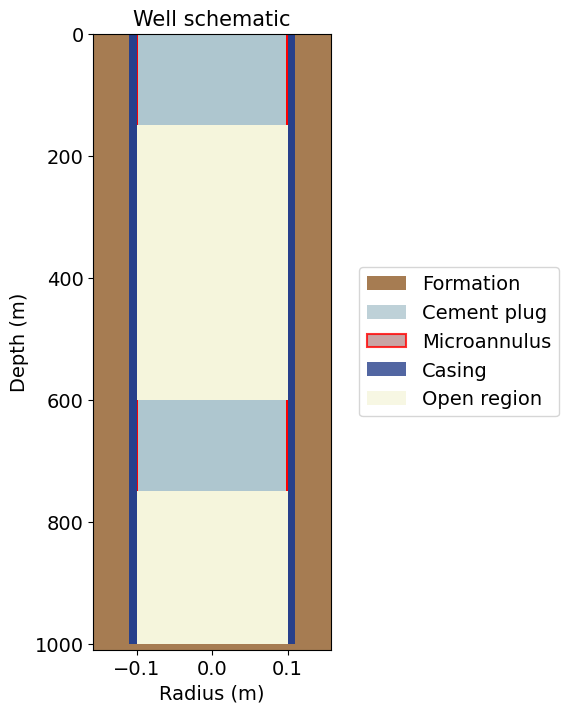

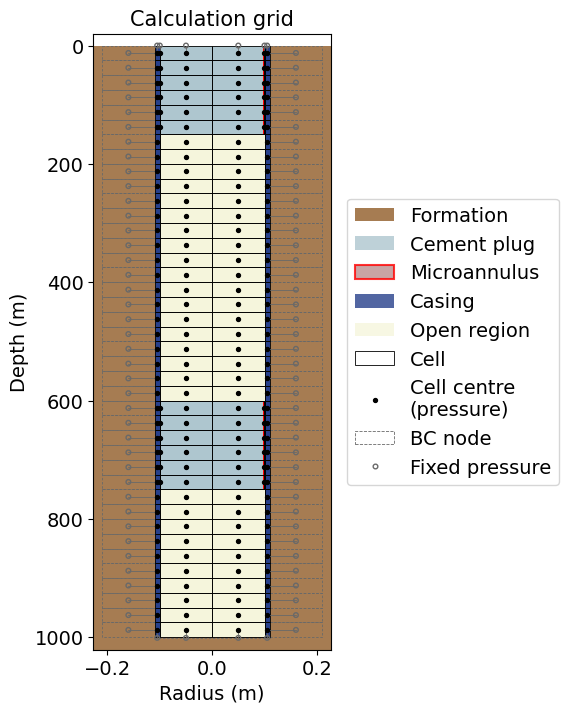

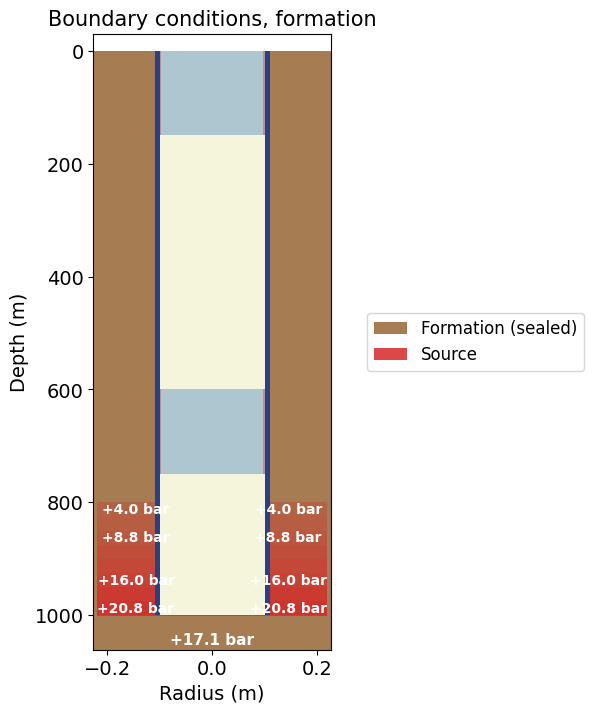

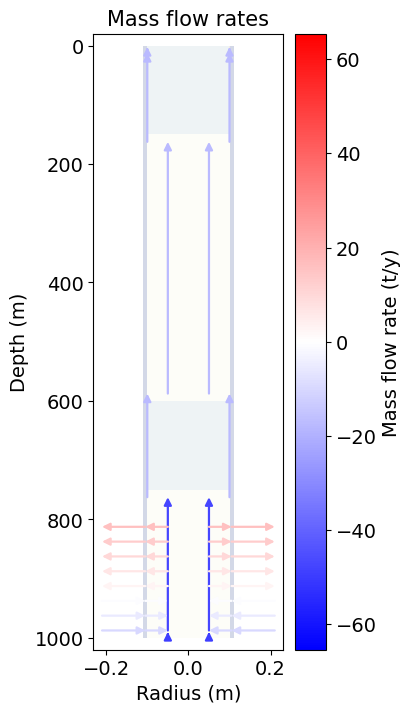

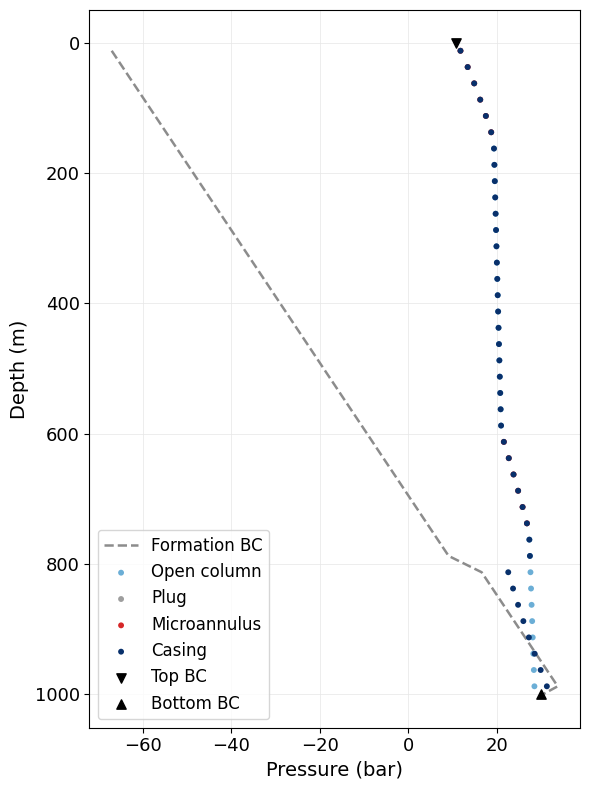

,bottom_anchored_visualization
0,work/benchmark/cases/round2_leakage_tool_proto...
1,work/benchmark/cases/round2_leakage_tool_proto...
2,work/benchmark/cases/round2_leakage_tool_proto...
3,work/benchmark/cases/round2_leakage_tool_proto...
4,work/benchmark/cases/round2_leakage_tool_proto...


In [ ]:
bottom_anchored_visualization_dir = round2_root / "prototype_visualizations_bottom_anchored"
bottom_anchored_visualization_dir.mkdir(parents=True, exist_ok=True)
bottom_anchored_fs.directory = str(bottom_anchored_visualization_dir)
visualizeAll(bottom_anchored_fs, bottom_anchored_result, show=True)

bottom_anchored_pngs = sorted(bottom_anchored_visualization_dir.glob("*.png"))
pd.DataFrame({
    "bottom_anchored_visualization": [
        path.relative_to(repo_root).as_posix() for path in bottom_anchored_pngs
    ]
})